##### Copyright 2026 Google LLC.

In [39]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Generate and edit videos with Gemini Omni Flash

<a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_Omni.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a> <!-- colab_logo_32px.png -->

_If you're reading this notebook on Github, open it in Colab by clicking the above button to see the generated videos._

Before diving in the code, you should try this capability on [AI Studio](https://aistudio.google.com/prompts/new_chat?model=gemini-omni-flash-preview). The [documentation](https://ai.google.dev/gemini-api/docs/omni) is also a good place to start discovering the Omni capability.

Gemini Omni Flash (`gemini-omni-flash-preview`) is a high-performance multimodal model designed for high-speed video generation, editing, and cinematic control. Powered by the [Interactions API](https://ai.google.dev/gemini-api/docs/interactions-overview), Omni introduces three core advancements:

*   **Built-in multimodality**: It processes text, image, audio, and video simultaneously, producing cohesive and consistent output across frames.
*   **Conversational editing**: Instead of generating standalone clips from scratch each time, you can iteratively edit videos through natural language turns. Describe what to change, and the model updates specific elements while preserving the rest of the scene.
*   **World knowledge**: By combining intuitive physics comprehension with broad historical, scientific, and cultural context, Omni bridges photorealism with meaningful storytelling.

This onboarding guide explains how to generate videos, traverse response steps and use the `.output_video` property, animate images created with Nano-Banana, perform multi-turn stateful editing, and understand when to prefer Omni versus Veo.

## Setup

### Install SDK

The Interactions API requires the latest `google-genai` SDK.

In [36]:
%pip install -U -q "google-genai>=2.10.0" # 2.10 is needed for the task parameter

To run the following cells, your API key must be stored in a Colab Secret named `GEMINI_API_KEY`. If you do not have an API key yet, create one in [Google AI Studio](https://aistudio.google.com/). For detailed instructions on API keys and authentication, see the [Authentication guide](./Authentication.ipynb).

In [37]:
from google import genai
from google.colab import userdata

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

Select the model you want to use in this guide:

In [38]:
MODEL_ID = "gemini-omni-flash-preview"  # @param ["gemini-omni-flash-preview"] {"allow-input":true, isTemplate: true}

## Generate videos with Omni

To generate a video purely from text instructions, call `client.interactions.create` with `model=MODEL_ID` and specify `"type": "video"` inside `response_format`:

In [40]:
interaction = client.interactions.create(
    model=MODEL_ID,
    input="A golden retriever running joyfully through a field of wildflowers at sunset.",
    response_format={"type": "video"},  # Optionnal
)

### Understanding API Outputs & The `.output_video` Shortcut

When you call `client.interactions.create(...)`, the API returns an `Interaction` response object. Because Omni is natively multi-modal and structured around conversational turns, the response contains an ordered sequence of **`steps`** representing the model's execution trajectory.

In [41]:
import json

# Trim 'data' and 'signature' fields across all steps and nested content parts
print(json.dumps([
    {**s.__dict__,
     **{k: v[:70] + '... (trimmed)' for k, v in s.__dict__.items() if k in ['data', 'signature'] and isinstance(v, str) and len(v) > 100},
     'content': [{**c.__dict__,
                  **{k: v[:70] + '... (trimmed)' for k, v in c.__dict__.items() if k == 'data' and isinstance(v, str) and len(v) > 100}}
                 for c in getattr(s, 'content', []) or []]}
    for s in interaction.steps
], indent=2))

[
  {
    "type": "thought",
    "signature": "EpcwCpQwAQw51sdIHNZALkCs5IRZCnpYdhlELCSywDOHgqahPhmAsSLONU9GcNCGhR5dhN... (trimmed)",
    "summary": null,
    "content": []
  },
  {
    "type": "model_output",
    "content": [
      {
        "type": "video",
        "data": "AAAAIGZ0eXBpc29tAAACAGlzb21pc28yYXZjMW1wNDEAABf5dXVpZNj+w9YbDkg8kpdYKI... (trimmed)",
        "uri": null,
        "mime_type": "video/mp4",
        "resolution": null
      }
    ],
    "error": null
  }
]


### Traversing output steps
Each step in `interaction.steps` has a `type`:
*   `thought`: Contains reasoning summaries when thinking is enabled.
*   `model_output`: Contains the final generated media content.

Inside a `model_output` step, `step.content` is a list of media parts (`text`, `image`, `audio`, or `video`). You can manually traverse these parts to inspect metadata or extract video bytes:

In [42]:
# Manually loop through steps to find the video part
for step in reversed(interaction.steps):
    if step.type == "model_output" and step.content:
        for part in reversed(step.content):
            if part.type == "video":
                display(Video(data=part.data, embed=True, mimetype=part.mime_type))
                break

Output hidden; open in https://colab.research.google.com to view.

### The `.output_video` convenience property
To simplify onboarding and everyday scripting, the `google-genai` SDK provides a direct shortcut property `.output_video` on the interaction response which always contains the last video generated:

In [43]:
# Access the generated video directly without inspecting steps
video_part = interaction.output_video
print(video_part.mime_type)  # e.g., 'video/mp4'
display(Video(data=video_part.data, embed=True, mimetype=video_part.mime_type))

Output hidden; open in https://colab.research.google.com to view.

To simplify the next code blocks, let's define helper functions using `IPython.display.Video` and `Markdown`:

In [44]:
# @title Display helpers
import base64
from IPython.display import Image, Markdown, Video, display


def get_output_video(interaction):
    """Retrieve the video part using .output_video or manual traversal."""
    if hasattr(interaction, "output_video") and interaction.output_video:
        return interaction.output_video
    if hasattr(interaction, "steps") and interaction.steps:
        for step in reversed(interaction.steps):
            if step.type == "model_output" and step.content:
                for content in reversed(step.content):
                    if content.type == "video":
                        return content
    return None


def get_output_image(interaction):
    """Retrieve the image part using .output_image or manual traversal."""
    if hasattr(interaction, "output_image") and interaction.output_image:
        return interaction.output_image
    if hasattr(interaction, "steps") and interaction.steps:
        for step in reversed(interaction.steps):
            if step.type == "model_output" and step.content:
                for content in reversed(step.content):
                    if content.type == "image":
                        return content
    return None


def show_video(interaction, width=640):
    """Render a video output inline in Colab using Video()."""
    output = get_output_video(interaction)
    if output is None or not getattr(output, "data", None):
        print("No video content found in interaction.")
        return
    mime = getattr(output, "mime_type", "video/mp4") or "video/mp4"
    display(Video(data=output.data, embed=True, mimetype=mime))


def show_thoughts(interaction):
    """Extract and display model thinking summaries formatted as Markdown."""
    if not hasattr(interaction, "steps") or not interaction.steps:
        return
    for step in interaction.steps:
        if step.type == "thought" and getattr(step, "summary", None):
            summary_items = step.summary
            if not isinstance(summary_items, list):
                summary_items = [summary_items]
            for item in summary_items:
                text = getattr(item, "text", str(item))
                display(Markdown(f"**🤔 Thought Summary:**\n\n{text}"))

### Managing Model Thinking & Reasoning

Gemini Omni Flash incorporates internal reasoning to plan physics, lighting, object interactions, and cinematic timing before synthesizing frames. You can manage thinking behavior inside `generation_config`:

*   **Enabling/controlling level**: Set `thinking_level` to `'low'` or `'high'` depending on task complexity. Setting `thinking_level='low'` effectively disables deep active reasoning (though minimal internal trajectory planning still occurs), while `'high'` enables full multi-step reasoning.
*   **Showing summaries**: Pass `thinking_summaries="auto"` to instruct the API to return a structured summary of the model's thought process inside a `thought` step.

Test generating a scientifically accurate stop-motion video with high reasoning enabled:

In [45]:
thinking_prompt = """
    claymation explainer of protein folding, everything is made out of clay,
    no hands, stop motion, accurate
"""

interaction_thinking = client.interactions.create(
    model=MODEL_ID,
    input=thinking_prompt,
    generation_config={
        "thinking_level": "high",
        "thinking_summaries": "auto",
    },
)

show_thoughts(interaction_thinking)
show_video(interaction_thinking)

Output hidden; open in https://colab.research.google.com to view.

### Control aspect ratio

By default, Omni generates videos in standard 16:9 widescreen format. You can generate vertical videos for mobile or social feeds by setting `aspect_ratio` to `"9:16"` inside `response_format`:

In [46]:
portrait_prompt = """
    A futuristic cyberpunk street corner at night with glowing neon rain, reflections on
    wet pavement, and flying vehicles passing overhead. Cinematic vertical establishing shot.
"""

interaction_portrait = client.interactions.create(
    model=MODEL_ID,
    input=portrait_prompt,
    response_format={
        "type": "video",  # optionnal
        "aspect_ratio": "9:16",
    },
)

show_video(interaction_portrait, width=360)

Output hidden; open in https://colab.research.google.com to view.

### World knowledge
Here is an example demonstrating deep world knowledge and scientific stop-motion accuracy:

In [60]:
world_knowledge_prompt = """
    The video shows items of the alphabet. An unusual item starting with each
    letter is shown sitting on a table (like a Capybara for C, disco globe for D
    and Lava Lamp for L). Show 3 to 5 letters at the same time, then move to the
    next group. All 26 letters must be represented by 26 items with matching lower
    thirds displaying the letter. Rapid fire, roughly 9 frames per item at 24FPS.
    Accompanied by calm smooth music.
"""

interaction_wk = client.interactions.create(
    model=MODEL_ID,
    input=world_knowledge_prompt,
)

show_video(interaction_wk)

Output hidden; open in https://colab.research.google.com to view.

## Image-to-Video

### Generating reference images

Instead of relying on external files or rudimentary graphics, you can use Gemini's image generation model (**Nano-Banana**, via `gemini-3.1-flash-lite-image`) to generate high-quality custom 16:9 reference artwork directly within your notebook workflow:

**Generated 16:9 Nano-Banana Reference Image:**

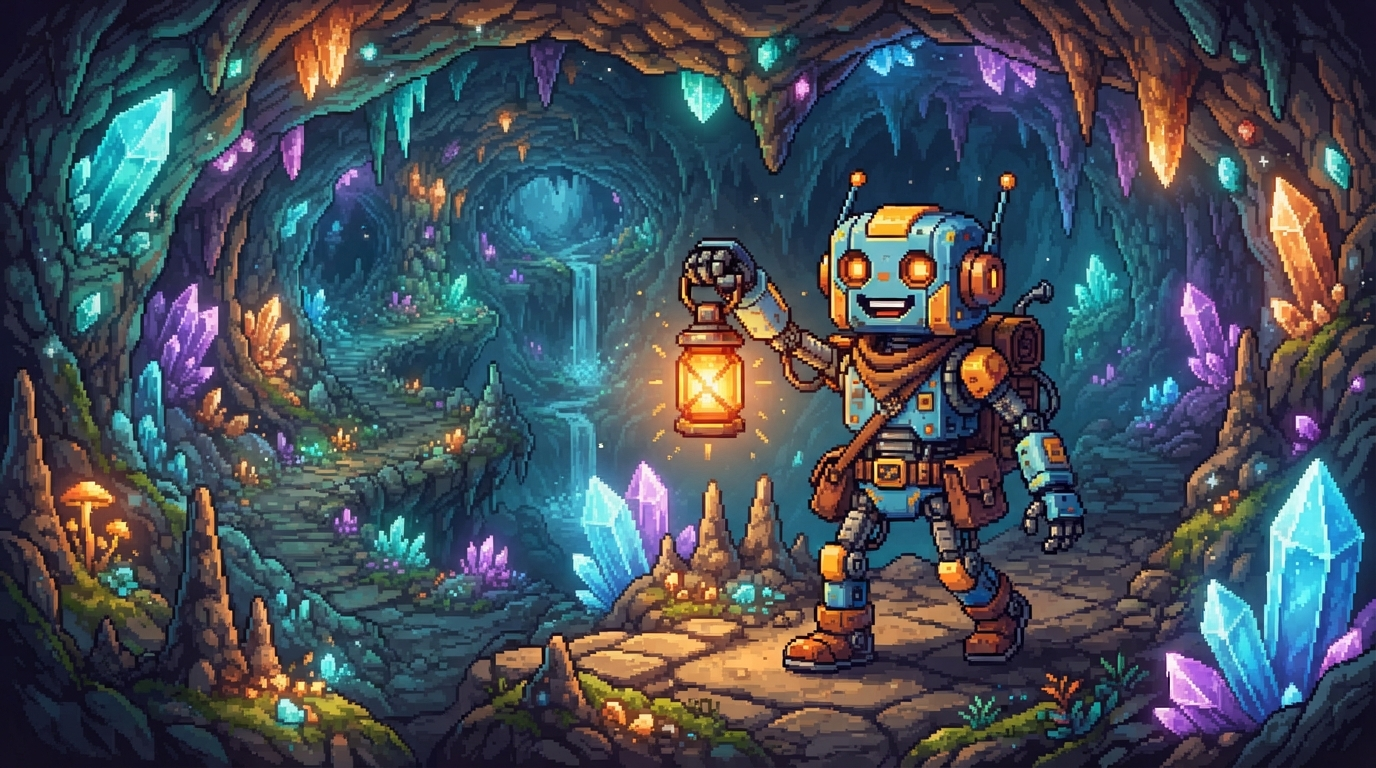

In [49]:
prompt = "Create a vibrant, detailed pixel art illustration of a cheerful robot adventurer holding a glowing amber lantern in an ancient crystal cavern." # @param {type:"string"}

# Generate a custom 16:9 reference image using Nano-Banana
interaction_img = client.interactions.create(
    model="gemini-3.1-flash-lite-image",
    input=prompt,
    response_modalities=["image"],
    generation_config={"image_config": {"aspect_ratio": "16:9"}},
)

# Extract image using .output_image or helper
image_part = get_output_image(interaction_img)

display(Markdown("**Generated 16:9 Nano-Banana Reference Image:**"))
if isinstance(image_part.data, str):
    display(Image(data=base64.b64decode(image_part.data)))
else:
    display(Image(data=image_part.data))

### Image-to-video (first frame)

To create a video that starts from the custom image you generated, pass both the image and your animation instructions into `input`.

Notice that `input` is structured as a list of dictionaries with different types (`{"type": "image", ...}` paired with `{"type": "text", ...}`). This multi-modal input list enables you to combine explicit visual starting compositions with natural language animation instructions simultaneously:

In [50]:
interaction_i2v = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "image", "data": image_part.data, "mime_type": image_part.mime_type},
        {
            "type": "text",
            "text": "Animate the robot raising its lantern high as shimmering crystal dust swirls gently around the cavern.",
        },
    ],
)

show_video(interaction_i2v)

Output hidden; open in https://colab.research.google.com to view.

### Direct Multi-Turn Transition from Nano-Banana to Omni

Because Nano-Banana (`gemini-3.1-flash-lite-image`) and Omni Flash share the unified Interactions API, you can skip extracting raw image bytes altogether. Instead, pass `previous_interaction_id=interaction_img.id` directly into Omni Flash to smoothly animate the image created in your previous turn:

In [65]:
animate_prompt = "Everything shakes as the cavern crumbles and and a dragon wakes up." # @param {type:"string"}

# Transition directly from Nano-Banana interaction_img.id into Omni Flash
interaction_nb_turn = client.interactions.create(
    model=MODEL_ID,
    previous_interaction_id=interaction_img.id,
    input=animate_prompt,
)

show_video(interaction_nb_turn)

Output hidden; open in https://colab.research.google.com to view.

### Reference(s)-to-video

In Reference-to-Video workflows, the provided image is **not** used as the literal starting frame. Instead, the model extracts the subject, character identity, or artistic composition and embeds it into a completely different environment or camera perspective.

In this example, notice how our Nano-Banana robot illustration is extracted as a reference subject and depicted as a framed painting hanging inside a cozy Victorian room:

In [52]:
ref_prompt = "A continuous handheld shot moving slowly through a cozy Victorian study with warm fireplace lighting. Hanging framed on the wooden wall is a painting depicting the exact scene from the reference image." # @param {type:"string"}

interaction_ref = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "image", "data": image_part.data, "mime_type": image_part.mime_type},
        {"type": "text", "text": ref_prompt},
    ],
    generation_config={"video_config": {"task": "reference_to_video"}},
)

show_video(interaction_ref)

Output hidden; open in https://colab.research.google.com to view.

### Advanced: Controlling Starting Frames vs. References (`task` parameter)

When given both images and text, Omni Flash infers whether to use an image as the literal opening frame (`image_to_video`) or as an indirect style/subject reference (`reference_to_video`). Occasionally, ambiguous multi-modal prompts can cause the model to mistake a reference image for a literal starting frame.

To guarantee precise execution in production pipelines, explicitly set the `task` parameter inside `generation_config.video_config` to either `"image_to_video"` or `"reference_to_video"`.

> **Important Note:** Specifying an explicit `task` parameter forces a standalone generation workflow and prevents you from chaining edits using `previous_interaction_id`.

In [76]:
# Explicit task parameter example
task_prompt = "A dragon's lair, but whose footsteps can be heard?" # @param {type:"string"}
interaction_task = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "image", "data": image_part.data, "mime_type": image_part.mime_type},
        {"type": "text", "text": task_prompt},
    ],
    generation_config={"video_config": {"task": "image_to_video"}},
)

show_video(interaction_task)

Output hidden; open in https://colab.research.google.com to view.

In [71]:
# Explicit task parameter example
task_prompt = "A dragon's lair, but whose footsteps can be heard?" # @param {type:"string"}
interaction_task = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "image", "data": image_part.data, "mime_type": image_part.mime_type},
        {"type": "text", "text": task_prompt},
    ],
    generation_config={"video_config": {"task": "reference_to_video"}},
)

show_video(interaction_task)

Output hidden; open in https://colab.research.google.com to view.

### Advanced: Use reference tags to control complex examples

For intricate multi-subject scenes, use explicit reference tags inside your text prompt to bind specific uploaded images to distinct roles:
*   `<FIRST_FRAME>`: Binds the image as the exact opening frame of the clip.
*   `<IMAGE_REF_0>`, `<IMAGE_REF_1>`, etc.: Binds images (0-indexed matching the order in `input`) to specific character identities, objects, or wardrobe items.

Omni Flash supports combining up to 5 reference images in a single call. Use Nano-Banana (`gemini-3.1-flash-lite-image`) below to generate 3 distinct characters alongside 3 matching accessories (6 images total), and then combine them into a unified campfire scene where each character wears their matching accessory:

In [54]:
# Generate 3 distinct characters and 3 matching accessories using Nano-Banana
char1 = client.interactions.create(model="gemini-3.1-flash-lite-image", input="Create a detailed digital illustration of a cheerful golden retriever puppy sitting happily on a plain white background.", response_modalities=["image"])
acc1 = client.interactions.create(model="gemini-3.1-flash-lite-image", input="Create a detailed illustration of a flowing bright red superhero cape on a plain white background.", response_modalities=["image"])
char2 = client.interactions.create(model="gemini-3.1-flash-lite-image", input="Create a detailed digital illustration of a wise little brown owl perched on a plain white background.", response_modalities=["image"])
acc2 = client.interactions.create(model="gemini-3.1-flash-lite-image", input="Create a detailed illustration of antique brass steampunk goggles on a plain white background.", response_modalities=["image"])
char3 = client.interactions.create(model="gemini-3.1-flash-lite-image", input="Create a detailed digital illustration of a friendly orange tabby cat sitting on a plain white background.", response_modalities=["image"])
acc3 = client.interactions.create(model="gemini-3.1-flash-lite-image", input="Create a detailed illustration of a pointed blue wizard hat decorated with golden stars on a plain white background.", response_modalities=["image"])

img_c1, img_a1 = get_output_image(char1), get_output_image(acc1)
img_c2, img_a2 = get_output_image(char2), get_output_image(acc2)
img_c3, img_a3 = get_output_image(char3), get_output_image(acc3)

def to_bytes(part):
    return base64.b64decode(part.data) if isinstance(part.data, str) else part.data

display(Markdown("**6 Nano-Banana Reference Images (3 Characters + 3 Accessories):**"))
display(Image(data=to_bytes(img_c1)))
display(Image(data=to_bytes(img_a1)))
display(Image(data=to_bytes(img_c2)))
display(Image(data=to_bytes(img_a2)))
display(Image(data=to_bytes(img_c3)))
display(Image(data=to_bytes(img_a3)))

Output hidden; open in https://colab.research.google.com to view.

Combine all six references into a unified scene using tags `<IMAGE_REF_0>` through `<IMAGE_REF_5>`:

In [72]:
multi_char_prompt = """
    In a single unbroken scene around a twilight campfire in a forest:
    <IMAGE_REF_0> is wearing <IMAGE_REF_5>,
    <IMAGE_REF_2> is wearing <IMAGE_REF_3>,
    and <IMAGE_REF_4> is wearing <IMAGE_REF_1>.
    They smile happily together as embers float into the evening sky.
"""

interaction_6refs = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "image", "data": img_c1.data, "mime_type": img_c1.mime_type},
        {"type": "image", "data": img_a1.data, "mime_type": img_a1.mime_type},
        {"type": "image", "data": img_c2.data, "mime_type": img_c2.mime_type},
        {"type": "image", "data": img_a2.data, "mime_type": img_a2.mime_type},
        {"type": "image", "data": img_c3.data, "mime_type": img_c3.mime_type},
        {"type": "image", "data": img_a3.data, "mime_type": img_a3.mime_type},
        {"type": "text", "text": multi_char_prompt},
    ],
    generation_config={"video_config": {"task": "reference_to_video"}},
)

show_video(interaction_6refs)

Output hidden; open in https://colab.research.google.com to view.

Notice how Omni Flash precisely bound each uploaded image pair to its respective character and accessory: the golden retriever puppy (`<IMAGE_REF_0>`) is wearing the starry blue wizard hat (`<IMAGE_REF_5>`), the brown owl (`<IMAGE_REF_2>`) is wearing the steampunk goggles (`<IMAGE_REF_3>`), and the orange tabby cat (`<IMAGE_REF_4>`) is wearing the red superhero cape (`<IMAGE_REF_1>`), all interacting naturally in a shared campfire environment without blending identities.

## Multi-Turn Conversational Video Editing

One of Omni's most powerful capabilities is multi-turn conversational video editing. Using the `previous_interaction_id` parameter, you can iteratively refine a generated clip across multiple conversation turns. The model maintains full state context, applying targeted modifications while preserving visual continuity.

Generate an initial clip in Turn 1, and then edit its style and elements in Turn 2:

In [56]:
# Turn 1: Generate the base video
turn1_prompt = "A sleek silver sports car driving smoothly down a coastal highway alongside the ocean at sunset." # @param {type:"string"}
turn1 = client.interactions.create(
    model=MODEL_ID,
    input=turn1_prompt,
)

print("Turn 1 Video (Base):")
show_video(turn1)

Output hidden; open in https://colab.research.google.com to view.

In [57]:
# Turn 2: Edit the previous generation by referencing turn1.id
turn2_prompt = "Change the car color to metallic blue. Keep everything else the same." # @param {type:"string"}
turn2 = client.interactions.create(
    model=MODEL_ID,
    previous_interaction_id=turn1.id,
    input=turn2_prompt,
)

print("Turn 2 Video (Edited):")
show_video(turn2)

Output hidden; open in https://colab.research.google.com to view.

Note that if you are using the `task` parameter to precisely control generation modes, it enforces a standalone generation step and prevents chaining multi-turn edits via `previous_interaction_id`.

### Editing Uploaded Videos

You can also edit your own real-world video footage by uploading it via the [Files API](https://ai.google.dev/gemini-api/docs/files) and passing its URI to the Interactions API.

> **Note:** Editing uploaded user videos is not currently available for users in the European Economic Area (EEA), Switzerland, and the United Kingdom (editing AI-generated clips as shown above is supported worldwide).

In [75]:
import time

file_name = "my_clip.mp4" # @param {type:"string"}

video_file = client.files.upload(file=file_name)

while video_file.state.name == "PROCESSING":
    time.sleep(5)
    video_file = client.files.get(name=video_file.name)

interaction_edit = client.interactions.create(
    model=MODEL_ID,
    input=[
        {"type": "document", "uri": video_file.uri},
        {"type": "text", "text": "Change the style of the video for a japanese animation. Keep main subject unchanged."},
    ],
)

show_video(interaction_edit)

Output hidden; open in https://colab.research.google.com to view.

## Retrieving Videos via URI Delivery (`delivery="uri"`)

When generating videos in production environments, the key benefit of requesting `delivery="uri"` inside `response_format` is **connection reliability and network resilience**. While standard inline delivery streams base64 data directly to your client, a temporary network interruption or browser tab refresh could interrupt the stream and lose the generated media.

By specifying `delivery="uri"`, the API hosts the finished video securely on Google Cloud storage and returns a persistent file identifier. Your application can poll the processing state and download the video reliably regardless of network drops:

In [87]:
import time

# 1. Request video with URI delivery for connection resilience
interaction_uri = client.interactions.create(
    model=MODEL_ID,
    input="A sweeping aerial drone shot of snowy mountain peaks at sunrise in a single unbroken scene.",
    response_format={
        "type": "video",
        "delivery": "uri"
    },
)

# 2. Extract file name and poll for ACTIVE state
video_output = interaction_uri.output_video
video_uri = video_output.uri
video_bytes = client.files.download(file=video_uri)
with open("mountain_sunrise.mp4", "wb") as f:
    f.write(video_bytes)

print(f"Downloaded mountain_sunrise.mp4 successfully from {video_uri}.")
display(Video("mountain_sunrise.mp4", embed=True))

Output hidden; open in https://colab.research.google.com to view.

## Prompting Guide & Best Practices

To get the most out of Gemini Omni Flash, apply these structured prompting techniques:

### Tip 1: Single scene continuity
By default, Omni may introduce multi-shot cinematic cuts to build narrative dynamism. To force a continuous, single-camera perspective, explicitly specify:
*   `"In a single unbroken scene..."`
*   `"Continuous handheld shot, no scene cuts..."`

In [88]:
tip1_prompt = "Continuous unbroken handheld shot of an ornate antique golden pocket watch resting on an open leather notebook, its second hand ticking smoothly forward." # @param {type:"string"}

interaction_tip1 = client.interactions.create(
    model=MODEL_ID,
    input=tip1_prompt,
)

show_video(interaction_tip1)

Output hidden; open in https://colab.research.google.com to view.

### Tip 2: Negative instructions
If unwanted elements appear, state clear prohibitions directly in natural language:
*   `"No dialogue or voiceover."`
*   `"No text overlay on screen."`

In [89]:
tip2_prompt = "A peaceful campfire glowing softly in a misty forest at dusk. No dialogue or voiceover. No text overlay on screen." # @param {type:"string"}

interaction_tip2 = client.interactions.create(
    model=MODEL_ID,
    input=tip2_prompt,
    response_format={"type": "video"},
)

show_video(interaction_tip2)

Output hidden; open in https://colab.research.google.com to view.

### Tip 3: Concise editing prompts
When performing multi-turn edits, keep instructions simple and surgical. Overly lengthy descriptions can confuse the diffing engine.
*   **Do:** `"Change the car color to metallic blue. Keep everything else the same."`
*   **Don't:** `"In the video showing the silver car driving down the road, please replace the silver paint with a metallic blue shade while making sure..."`

In [90]:
# Surgical multi-turn edit example
edit_prompt = "Add glowing purple neon underglow lights under the car. Keep everything else the same." # @param {type:"string"}
interaction_edit = client.interactions.create(
    model=MODEL_ID,
    previous_interaction_id=turn1.id,
    input=edit_prompt,
)
show_video(interaction_edit)

Output hidden; open in https://colab.research.google.com to view.

### Tip 4: Timing & Chronological Choreography

You can prompt for actions to occur at specific timestamps inside your video using either natural language descriptions or bracketed timecode syntax (`[0-3s]`, `[3-6s]`). This gives you full directorial control over scene rhythm, pacing, and multi-beat storytelling:

*   **Natural language timing**: `"after 3 seconds, a woman enters the scene"`, `"at 5s the chorus starts in the background audio"`.
*   **Bracketed timecode syntax**: `"[0-3s] A person is walking. [3-6s] They stop and turn around. [6-10s] They start running."`

In [91]:
timing_prompt = "[0-3s] A continuous handheld shot of a woman in a red coat standing still on a snowy city sidewalk looking forward. [3-6s] She slowly opens a bright yellow umbrella as soft snowflakes fall around her." # @param {type:"string"}

interaction_timing = client.interactions.create(
    model=MODEL_ID,
    input=timing_prompt,
    response_format={"type": "video"},
)

show_video(interaction_timing)

### Tip 5: Key moments understanding

You can also prompt the model to do edit the video when some specific action happens.

In [93]:
tip5_turn1_prompt = "A person stands in front of a mirror. At 0:05, she touches the mirror then she does it again at 0:07, 0:08 and 0:09" # @param {type:"string"}
tip5_turn1 = client.interactions.create(
    model=MODEL_ID,
    input=tip5_turn1_prompt,
)

print("Turn 1 Video (Base):")
show_video(tip5_turn1)

Output hidden; open in https://colab.research.google.com to view.

In [95]:
tip5_turn2_prompt = "The style of the video changes every time the person touches the mirror" # @param {type:"string"}
tip5_turn2 = client.interactions.create(
    model=MODEL_ID,
    input=tip5_turn2_prompt,
    previous_interaction_id=tip5_turn1.id,
)

print("Turn 2 Video (Edited):")
show_video(tip5_turn2)

Output hidden; open in https://colab.research.google.com to view.

## Veo vs. Omni: Choosing the Right Model

Google offers two premier video generation model families: **Gemini Omni Flash** and **Veo**. Understanding their distinct architectures helps you select the right tool for your application.

| Capability | Gemini Omni Flash (`gemini-omni-flash-preview`) | Veo (`veo-2.0-generate-001`) |
| :--- | :--- | :--- |
| **Primary API** | **Interactions API** (`client.interactions.create`) | **Models API** (`client.models.generate_videos`) |
| **Core Strength** | High-speed conversational editing & multi-modal synthesis | Dedicated studio-grade video generation |
| **Stateful Editing** | ✅ **Yes** (Multi-turn editing via `previous_interaction_id`) | ❌ No (Unary generation per call) |
| **Multi-Image R2V** | ✅ **Up to 5 reference images & 5 audio tracks** | ⚠️ Single image reference / prompt |
| **Motion & Dynamics** | Dynamic, engaging motion and complex storyline pacing | High visual fidelity and cinematic realism |
| **Text Interleaving** | Accurate text rendering on signs/objects within scenes | Strict isolation (no interleaved text overlays) |

### When to prefer Gemini Omni Flash:
*   **Conversational workflows**: Iterative multi-turn editing where users refine clips via dialogue.
*   **Complex reasoning**: Prompts requiring deep world knowledge, physics understanding, or multi-modal fusion.
*   **Rich referencing**: Tasks combining multiple reference characters, product images, and style guides.

### When to continue using Veo:
*   **High-throughput economy**: **Veo 3.1 Lite** offers the most competitive quality-versus-cost trade-off for batch clip generation.
*   **Resolution requirements**: Ultra-high definition 1080p and 4K output pipelines.
*   **Structural video tasks**: Video extension and first-to-last frame interpolation workflows.
*   **Pure clip synthesis**: Automated pipelines requiring standalone B-roll clips without shot cuts or conversational overhead.

## Next Steps

*   Explore the official [Interactions API Overview](https://ai.google.dev/gemini-api/docs/interactions-overview).
*   Read the [Gemini Omni Documentation](https://ai.google.dev/gemini-api/docs/omni) and [Veo Documentation](https://ai.google.dev/gemini-api/docs/veo).
*   Review [Gemini API Pricing](https://ai.google.dev/gemini-api/docs/pricing) for video generation tiers.
*   Check out the [Introduction to Prompt Design](https://ai.google.dev/gemini-api/docs/prompting-intro) for advanced prompting strategies.